**Кластеризация латентных представлений для типизации режимов скважин**

**Цель**: Получить устойчивые кластеры в латентном пространстве автоэнкодера,
интерпретировать каждый кластер как типовой режим работы скважины и сравнить
качество разделения с baseline (EDA этап, Уровни 1–2).

**Входные данные**:
- models/ecn/model.pth   — лучший автоэнкодер ЭЦН (GRU, latent_dim=32)
- models/shgn/model.pth  — лучший автоэнкодер ШГН (Hybrid, latent_dim=8)
- data/processed/ecn_*.csv        — нормализованные временные ряды ЭЦН
- data/processed/shgn_*.csv       — нормализованные временные ряды ШГН

**Этапы**:
1. Загрузка моделей и данных
2. Кодирование всего датасета → матрица латентных векторов
3. Подбор числа кластеров (Elbow + Silhouette)
4. K-Means кластеризация + сохранение центроидов
5. Оценка качества: Silhouette, Davies-Bouldin, Calinski-Harabasz
6. Визуализация латентного пространства (PCA-2D / UMAP)
7. Интерпретация кластеров: декодирование центроидов → типовые профили
8. Сохранение артефактов кластеризации

**Выходные данные**:
- models/ecn/ecn_kmeans.pkl   — K-Means модель ЭЦН
- models/shgn/shgn_kmeans.pkl  — K-Means модель ШГН
- models/ecn/ecn_labels.npy   — метки кластеров для всех окон ЭЦН
- models/shgn/shgn_labels.npy  — метки кластеров для всех окон ШГН
- models/ecn/ecn_latents.npy  — латентные векторы ЭЦН
- models/shgn/shgn_latents.npy — латентные векторы ШГН

In [39]:
import logging
import pickle
import sys
import warnings
from pathlib import Path
from typing import Any, Protocol

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler, normalize
from torchinfo import summary
from umap import UMAP

sys.path.insert(0, str(Path("../models").resolve()))
from models import build_model

# ==== 1. ЗАГРУЗКА МОДЕЛЕЙ И ДАННЫХ ====

In [8]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler()],
)
logger = logging.getLogger(__name__)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Устройство: {DEVICE}")

2026-02-23 21:54:33,668 - INFO - Устройство: cuda


In [44]:
COLORS: dict[str, str] = {
    "primary": "#2E86AB",
    "secondary": "#A23B72",
    "accent": "#F18F01",
    "success": "#C73E1D",
    "neutral": "#6B7280",
}
CLUSTER_PALETTE: list[str] = [
    "#2E86AB",
    "#A23B72",
    "#F18F01",
    "#C73E1D",
    "#4CAF50",
    "#9C27B0",
]

plt.rcParams.update(
    {
        "figure.figsize": (15, 6),
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 100,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
    }
)

FEATURE_COLUMNS: list[str] = [
    "us_center",
    "us_periph",
    "gas_center",
    "gas_periph",
    "temp",
    "water_center",
    "water_periph",
    "gas_integral",
    "water_integral",
]
WINDOW_SIZES: dict[str, int] = {"ecn": 120, "shgn": 100}
STRIDES: dict[str, int] = {"ecn": 20, "shgn": 15}
N_CLUSTERS: dict[str, int] = {"ecn": 3, "shgn": 4}

MODEL_HYPERPARAMS: dict[str, Any] = {
    "input_dim": len(FEATURE_COLUMNS),
    "hidden_size": 192,
    "num_layers": 2,
    "kernel_size": 5,
    "dilation_base": 2,
    "dropout": 0.15,
}

DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

In [16]:
def _windows_from_array(X: np.ndarray, window_size: int, stride: int) -> np.ndarray:
    if len(X) < window_size:
        return np.empty((0, window_size, X.shape[1]), dtype=np.float32)
    w = sliding_window_view(X, window_shape=window_size, axis=0)[::stride]
    return np.transpose(w, (0, 2, 1)).astype(np.float32)

In [17]:
def load_windows(prefix: str) -> tuple[np.ndarray, StandardScaler]:
    with open(DATA_DIR / f"scaler_{prefix}.pkl", "rb") as f:
        scaler: StandardScaler = pickle.load(f)

    window_size = WINDOW_SIZES[prefix]
    stride = STRIDES[prefix]

    parts = [
        _windows_from_array(
            np.load(DATA_DIR / f"X_{prefix}_{split}.npy").astype(np.float32),
            window_size,
            stride,
        )
        for split in ("train", "val", "test")
    ]
    X = np.concatenate([p for p in parts if len(p) > 0])
    logger.info(f"{prefix.upper()}: всего окон={X.shape[0]} | shape={X.shape}")
    return X, scaler

In [18]:
X_ecn, scaler_ecn = load_windows("ecn")
X_shgn, scaler_shgn = load_windows("shgn")

2026-02-23 21:57:04,053 - INFO - ECN: всего окон=2052 | shape=(2052, 120, 9)
2026-02-23 21:57:04,079 - INFO - SHGN: всего окон=8343 | shape=(8343, 100, 9)


# ==== 2. ЗАГРУЗКА ВЕСОВ И КОДИРОВАНИЕ ====

In [29]:
class Encodable(Protocol):
    def encode(self, x: torch.Tensor) -> torch.Tensor: ...

In [36]:
def load_model(prefix: str) -> tuple[nn.Module, dict[str, Any]]:
    checkpoint: dict[str, Any] = torch.load(MODELS_DIR / prefix / "model.pth", map_location=DEVICE, weights_only=False)
    hp = MODEL_HYPERPARAMS
    model = build_model(
        arch_name=checkpoint["architecture"],
        input_dim=hp["input_dim"],
        hidden_size=hp["hidden_size"],
        latent_dim=checkpoint["latent_dim"],
        num_layers=hp["num_layers"],
        kernel_size=hp["kernel_size"],
        dilation_base=hp["dilation_base"],
        dropout=hp["dropout"],
    ).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    logger.info(
        f"{prefix.upper()}: arch={checkpoint['architecture']} | latent_dim={checkpoint['latent_dim']} | metrics={checkpoint['metrics']}"
    )
    return model, checkpoint

In [37]:
model_ecn, ckpt_ecn = load_model("ecn")
model_shgn, ckpt_shgn = load_model("shgn")

2026-02-23 22:02:15,145 - INFO - ECN: arch=GRU | latent_dim=32 | metrics={'val_loss': 0.11795883866426704, 'val_mae': 0.06856070910869677, 'test_loss': 0.12046007841032323, 'test_mae': 0.08296228105336041}


2026-02-23 22:02:15,175 - INFO - SHGN: arch=Hybrid | latent_dim=8 | metrics={'val_loss': 0.3844532113808852, 'val_mae': 0.5290358506716215, 'test_loss': 0.43648395553613323, 'test_mae': 0.5832279706612612}


In [38]:
for prefix, model, window_size in (
    ("ЭЦН", model_ecn, WINDOW_SIZES["ecn"]),
    ("ШГН", model_shgn, WINDOW_SIZES["shgn"]),
):
    model_summary = summary(
        model,
        input_size=(1, window_size, len(FEATURE_COLUMNS)),
        col_names=["input_size", "output_size", "num_params"],
        depth=3,
        verbose=0,
    )
    logger.info(f"\n{prefix}:\n{model_summary}")

2026-02-23 22:02:16,417 - INFO - 
ЭЦН:
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
GRUAutoencoder                           [1, 120, 9]               [1, 120, 9]               --
├─GRU: 1-1                               [1, 120, 9]               [1, 120, 384]             899,712
├─AttentionPool: 1-2                     [1, 120, 384]             [1, 384]                  --
│    └─Linear: 2-1                       [1, 120, 384]             [1, 120, 1]               385
├─Linear: 1-3                            [1, 384]                  [1, 32]                   12,320
├─Linear: 1-4                            [1, 32]                   [1, 384]                  12,672
├─GRU: 1-5                               [1, 120, 9]               [1, 120, 192]             339,264
├─Linear: 1-6                            [1, 120, 192]             [1, 120, 9]               1,737
Total params: 1,266,090
Trainable params: 1,266,090
Non-trainable para

In [27]:
def encode_dataset(model: Encodable, X: np.ndarray, batch_size: int = 512) -> np.ndarray:
    latents: list[np.ndarray] = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            batch = torch.from_numpy(X[start : start + batch_size]).float().to(DEVICE)
            z = model.encode(batch)
            latents.append(z.cpu().numpy())
    return np.concatenate(latents)

In [40]:
Z_ecn = normalize(encode_dataset(model_ecn, X_ecn), norm="l2")
Z_shgn = normalize(encode_dataset(model_shgn, X_shgn), norm="l2")
logger.info(f"ЭЦН латенты: {Z_ecn.shape} | ШГН латенты: {Z_shgn.shape}")

2026-02-23 22:02:35,112 - INFO - ЭЦН латенты: (2052, 32) | ШГН латенты: (8343, 8)


# ==== 3. ПОДБОР ЧИСЛА КЛАСТЕРОВ ====

In [45]:
def plot_elbow_silhouette(Z: np.ndarray, pump_type: str, k_range: range = range(2, 9)) -> int:
    inertias: list[float] = []
    silhouettes: list[float] = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        labels = km.fit_predict(Z)
        inertias.append(float(km.inertia_))
        silhouettes.append(float(silhouette_score(Z, labels, sample_size=min(5000, len(Z)), random_state=SEED)))

    k_list = list(k_range)
    best_k = k_list[int(np.argmax(silhouettes))]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(k_list, inertias, marker="o", color=COLORS["primary"], linewidth=2)
    ax1.set_title("Elbow (инерция)")
    ax1.set_xlabel("Число кластеров k")
    ax1.set_ylabel("Inertia")

    ax2.plot(k_list, silhouettes, marker="o", color=COLORS["secondary"], linewidth=2)
    ax2.axvline(x=best_k, color=COLORS["accent"], linestyle="--", linewidth=1.5, label=f"best k={best_k}")
    ax2.set_title("Silhouette Score")
    ax2.set_xlabel("Число кластеров k")
    ax2.set_ylabel("Silhouette")
    ax2.legend()

    fig.suptitle(f"{pump_type}: подбор числа кластеров", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    logger.info(f"{pump_type}: лучший k по Silhouette = {best_k} ({max(silhouettes):.4f})")
    return best_k

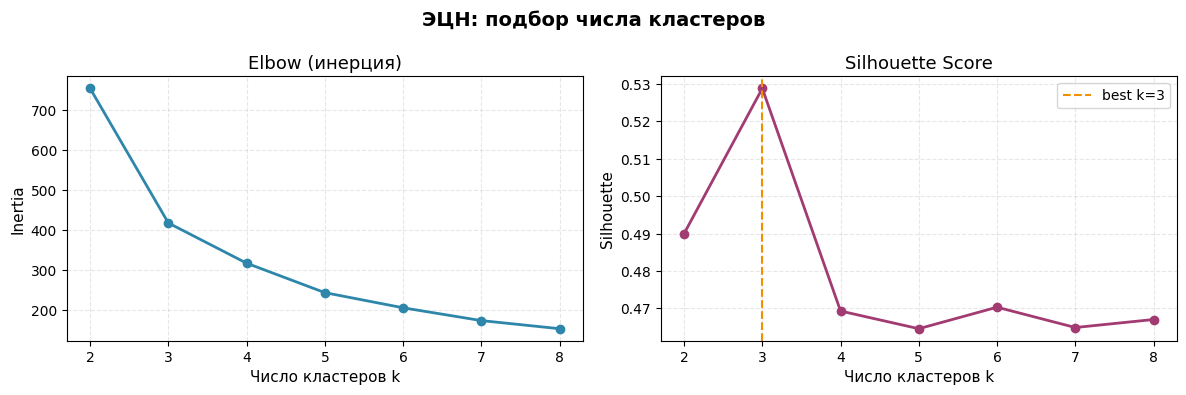

2026-02-23 22:07:31,651 - INFO - ЭЦН: лучший k по Silhouette = 3 (0.5288)


In [46]:
N_CLUSTERS["ecn"] = plot_elbow_silhouette(Z_ecn, "ЭЦН")

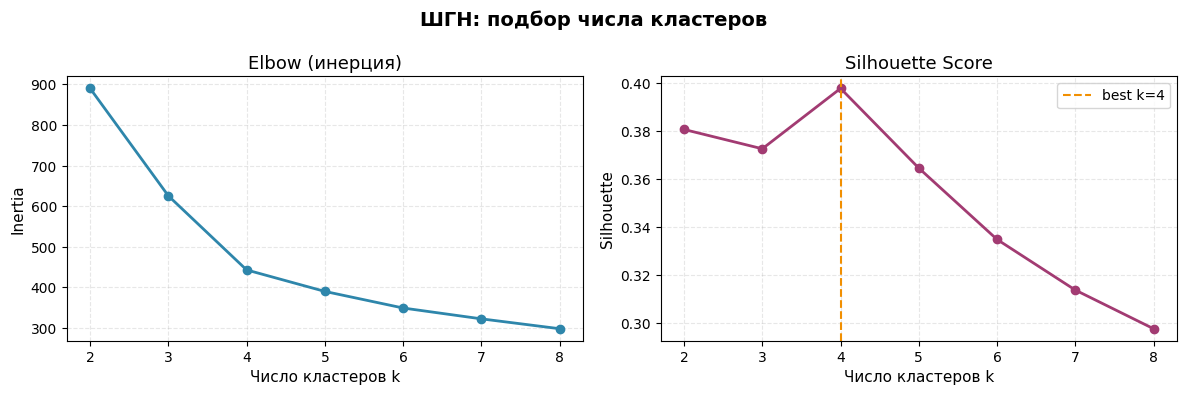

2026-02-23 22:07:36,451 - INFO - ШГН: лучший k по Silhouette = 4 (0.3976)


In [47]:
N_CLUSTERS["shgn"] = plot_elbow_silhouette(Z_shgn, "ШГН")

# ==== 4. K-MEANS КЛАСТЕРИЗАЦИЯ ====

In [49]:
def fit_kmeans(Z: np.ndarray, n_clusters: int, pump_type: str) -> tuple[KMeans, np.ndarray]:
    km = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=20)
    labels = km.fit_predict(Z)

    sil = silhouette_score(Z, labels, sample_size=min(5000, len(Z)), random_state=SEED)
    db = davies_bouldin_score(Z, labels)
    ch = calinski_harabasz_score(Z, labels)

    logger.info(
        f"{pump_type} | k={n_clusters} | Silhouette={sil:.4f} | Davies-Bouldin={db:.4f} | Calinski-Harabasz={ch:.1f}"
    )
    return km, labels

In [50]:
km_ecn, labels_ecn = fit_kmeans(Z_ecn, N_CLUSTERS["ecn"], "ЭЦН")
km_shgn, labels_shgn = fit_kmeans(Z_shgn, N_CLUSTERS["shgn"], "ШГН")

2026-02-23 22:07:54,633 - INFO - ЭЦН | k=3 | Silhouette=0.5288 | Davies-Bouldin=0.7058 | Calinski-Harabasz=2512.0
2026-02-23 22:07:54,954 - INFO - ШГН | k=4 | Silhouette=0.3976 | Davies-Bouldin=0.9407 | Calinski-Harabasz=7286.0


# ==== 5. ВИЗУАЛИЗАЦИЯ ЛАТЕНТНОГО ПРОСТРАНСТВА ====

In [51]:
def _reduce_to_2d(Z: np.ndarray, method: str) -> tuple[np.ndarray, str]:
    if method == "PCA":
        reducer = PCA(n_components=2, random_state=SEED)
        Z_2d = np.asarray(reducer.fit_transform(Z))
        explained = float(reducer.explained_variance_ratio_.sum())
        return Z_2d, f"PCA (объяснённая дисперсия: {explained:.1%})"

    reducer_umap = UMAP(n_components=2, random_state=SEED, n_neighbors=30, min_dist=0.1)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        Z_2d = np.asarray(reducer_umap.fit_transform(Z))
    return Z_2d, "UMAP"


def plot_latent_space(
    Z: np.ndarray,
    labels: np.ndarray,
    pump_type: str,
    method: str = "PCA",
) -> None:
    Z_2d, subtitle = _reduce_to_2d(Z, method)
    unique_labels = np.unique(labels)

    fig, ax = plt.subplots(figsize=(10, 7))
    for k in unique_labels:
        mask = labels == k
        ax.scatter(
            Z_2d[mask, 0],
            Z_2d[mask, 1],
            c=CLUSTER_PALETTE[k % len(CLUSTER_PALETTE)],
            label=f"Кластер {k} (n={int(mask.sum())})",
            alpha=0.5,
            s=8,
            rasterized=True,
        )

    ax.set_title(f"{pump_type}: латентное пространство — {subtitle}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Компонента 1")
    ax.set_ylabel("Компонента 2")
    ax.legend(markerscale=3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

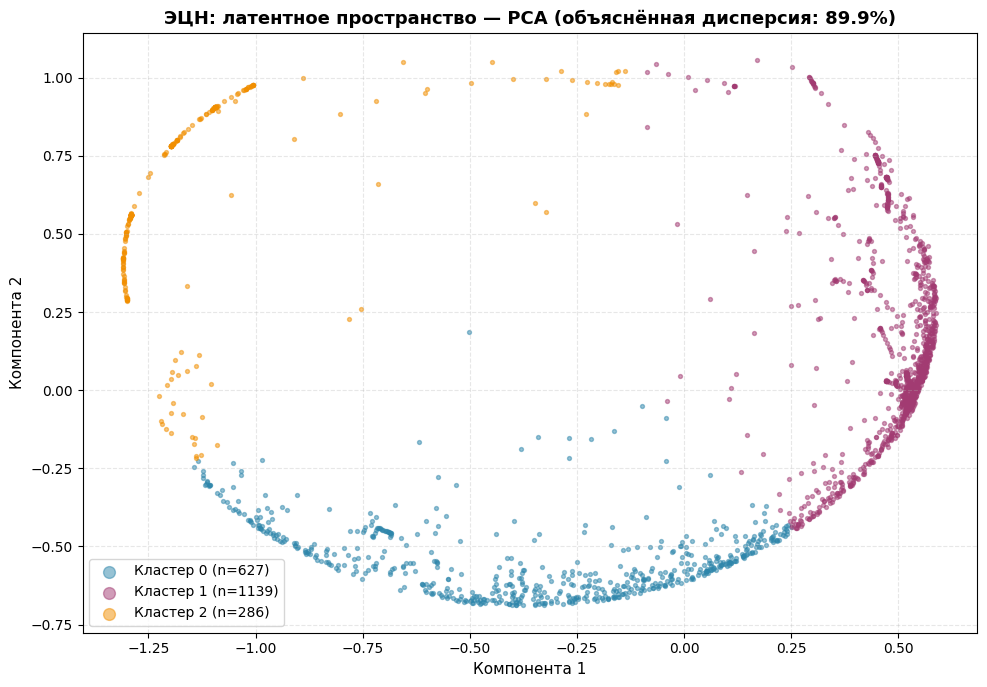

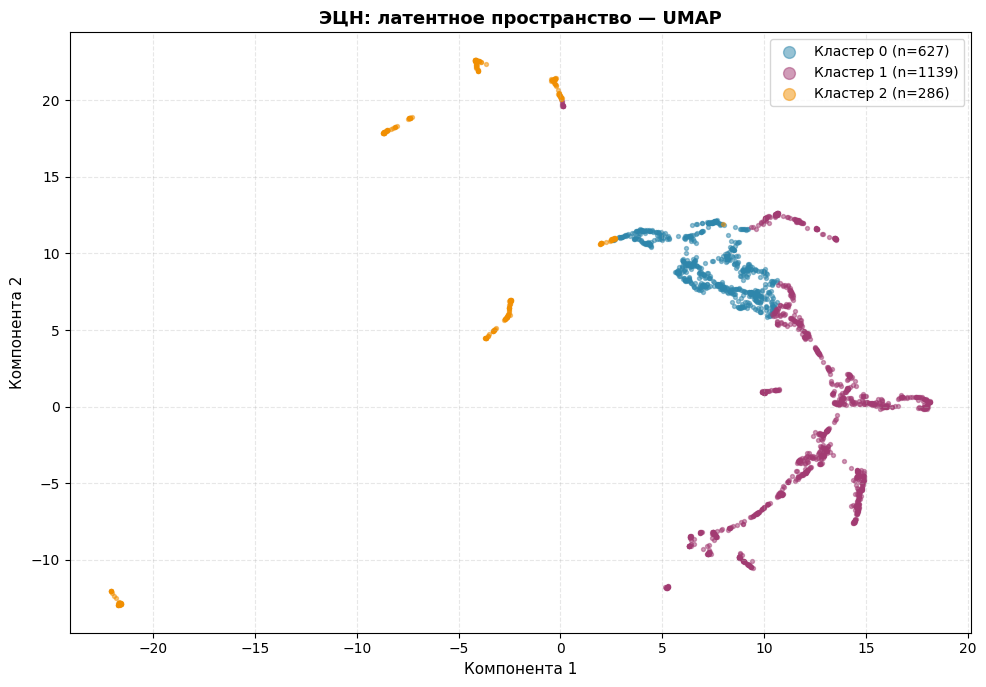

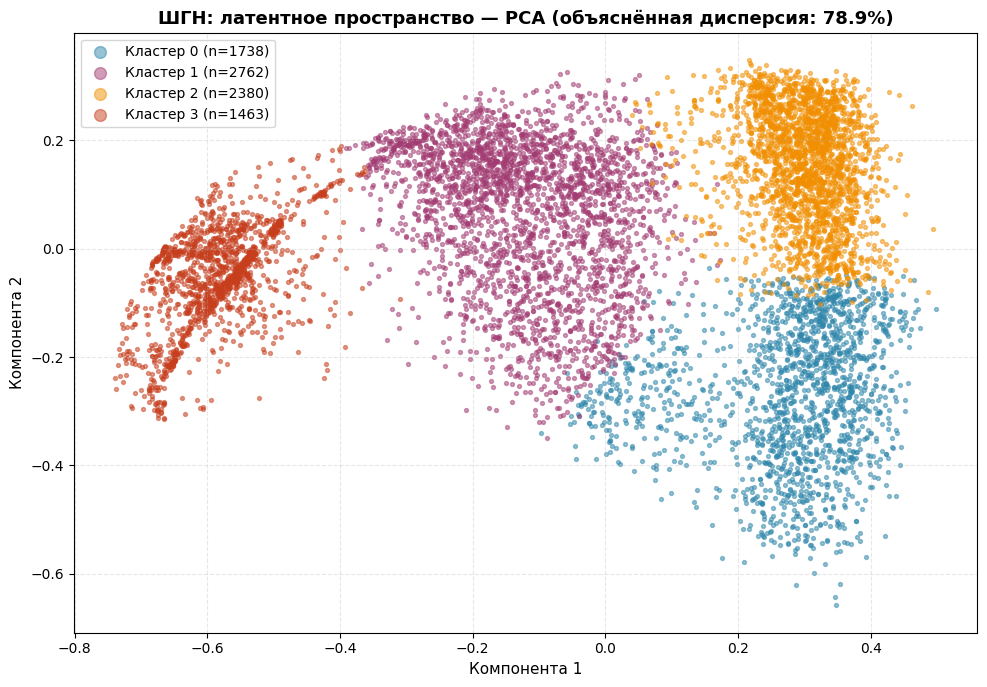

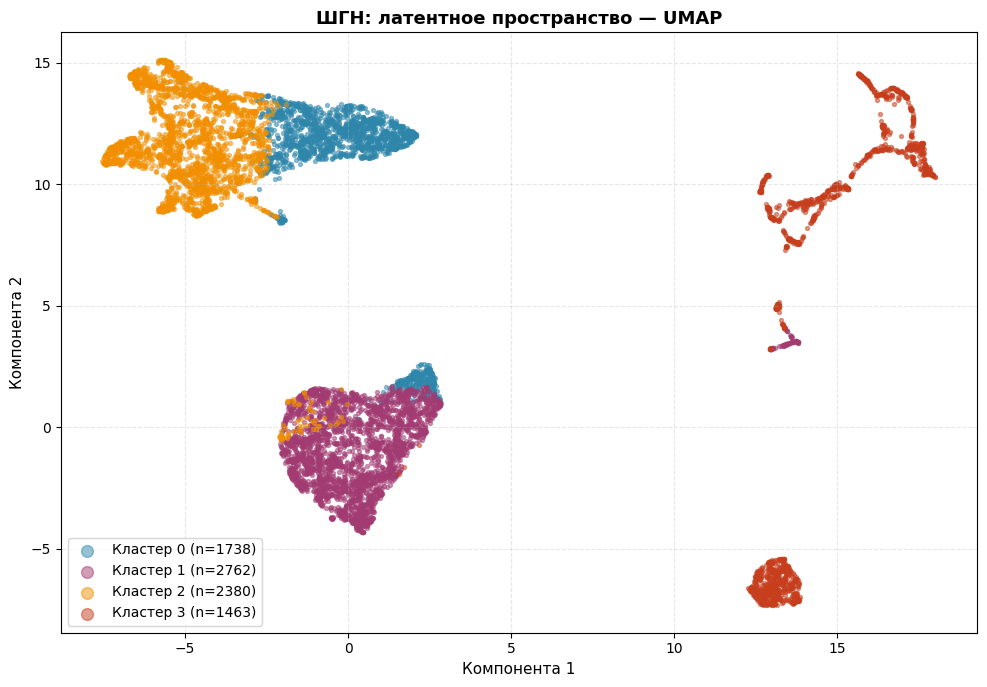

In [52]:
for pump_type, Z, labels in (("ЭЦН", Z_ecn, labels_ecn), ("ШГН", Z_shgn, labels_shgn)):
    for method in ("PCA", "UMAP"):
        plot_latent_space(Z, labels, pump_type, method)

# ==== 6. ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ ====

In [57]:
def decode_centroid_by_nearest(
    Z: np.ndarray,
    X: np.ndarray,
    centroid: np.ndarray,
    n_neighbors: int = 50,
) -> np.ndarray:
    dists = np.linalg.norm(Z - centroid, axis=1)
    nearest_idx = np.argsort(dists)[:n_neighbors]
    return X[nearest_idx].mean(axis=0)

In [73]:
def plot_cluster_profiles(
    Z: np.ndarray,
    X: np.ndarray,
    km: KMeans,
    pump_type: str,
    n_clusters: int,
    n_neighbors: int = 50,
) -> None:
    steps = np.arange(X.shape[1])
    fig, axes = plt.subplots(n_clusters, len(FEATURE_COLUMNS), figsize=(22, 3 * n_clusters))

    for k in range(n_clusters):
        profile = decode_centroid_by_nearest(Z, X, km.cluster_centers_[k], n_neighbors)
        row_axes = axes[k] if n_clusters > 1 else axes

        for j, feature in enumerate(FEATURE_COLUMNS):
            ax = row_axes[j]
            ax.plot(steps, profile[:, j], color=CLUSTER_PALETTE[k % len(CLUSTER_PALETTE)], linewidth=1.5)
            if k == 0:
                ax.set_title(feature, fontsize=9, fontweight="bold")
            if j == 0:
                ax.set_ylabel(f"Кластер {k}", fontsize=9)

    fig.suptitle(
        f"{pump_type}: типовые профили кластеров",
        fontsize=13,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()
    plt.close(fig)

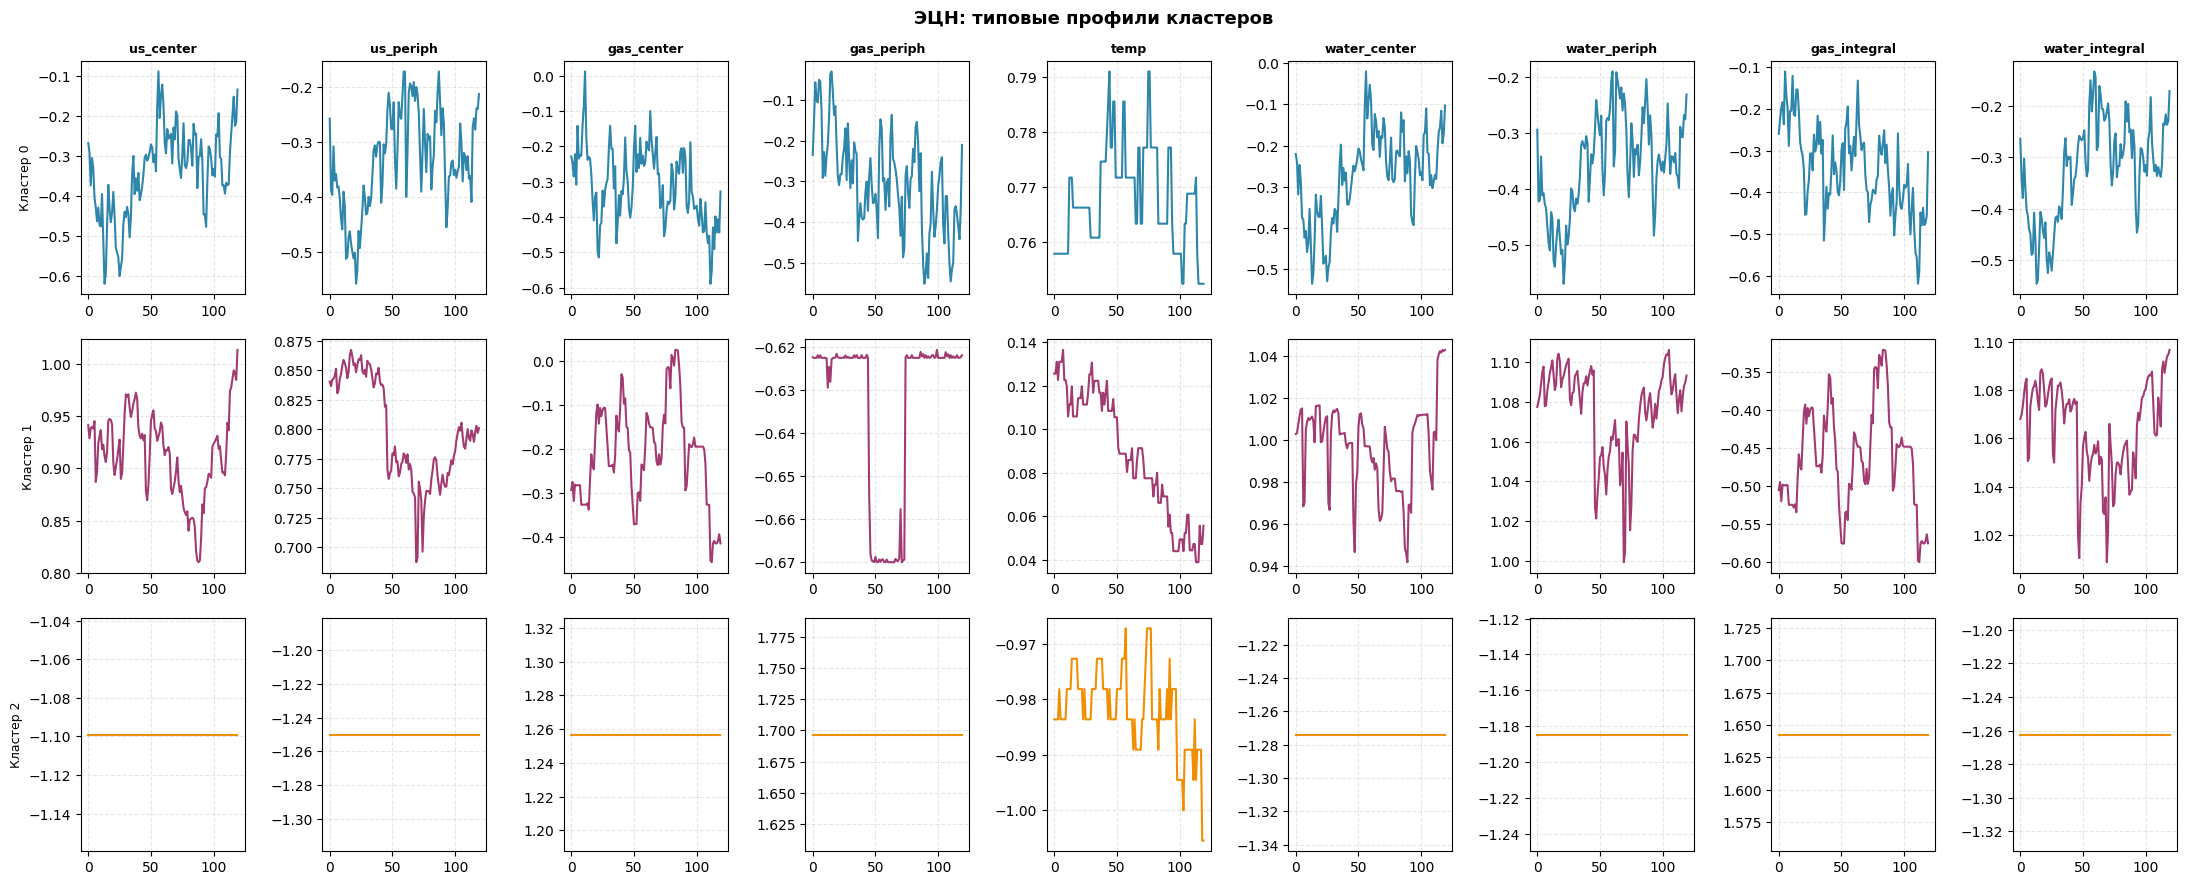

In [74]:
plot_cluster_profiles(Z_ecn, X_ecn, km_ecn, "ЭЦН", N_CLUSTERS["ecn"])

| Кластер | Состояние         | Обоснование                                                                                                                                                                                                                                                                 |
| ------- | ----------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 0       | Запуск            | УЗ и обводнённость растут (+0.13, +0.12) от начала к концу окна — насос разгоняется. Температура уже высокая (+0.76) — оборудование прогрето. Параметры ещё не вышли на рабочий уровень, но явно идут вверх                                                                 |
| 1       | Стабильная работа | УЗ максимальный (+0.91–1.01), обводнённость максимальная (+1.0–1.09), газосодержание минимальное (−0.62). Тренды малые (~0.07) — режим устойчивый, насос гонит жидкость в штатном режиме                                                                                    |
| 2       | Выключена         | Тренд по всем параметрам = 0.0 — абсолютная константа на протяжении всего окна. УЗ минимальный (−1.1, −1.25), газосодержание максимальное (+1.26, +1.70) — труба заполнена газом, жидкость не движется. Температура минимальная (−0.98) — насос холодный, давно не работает |

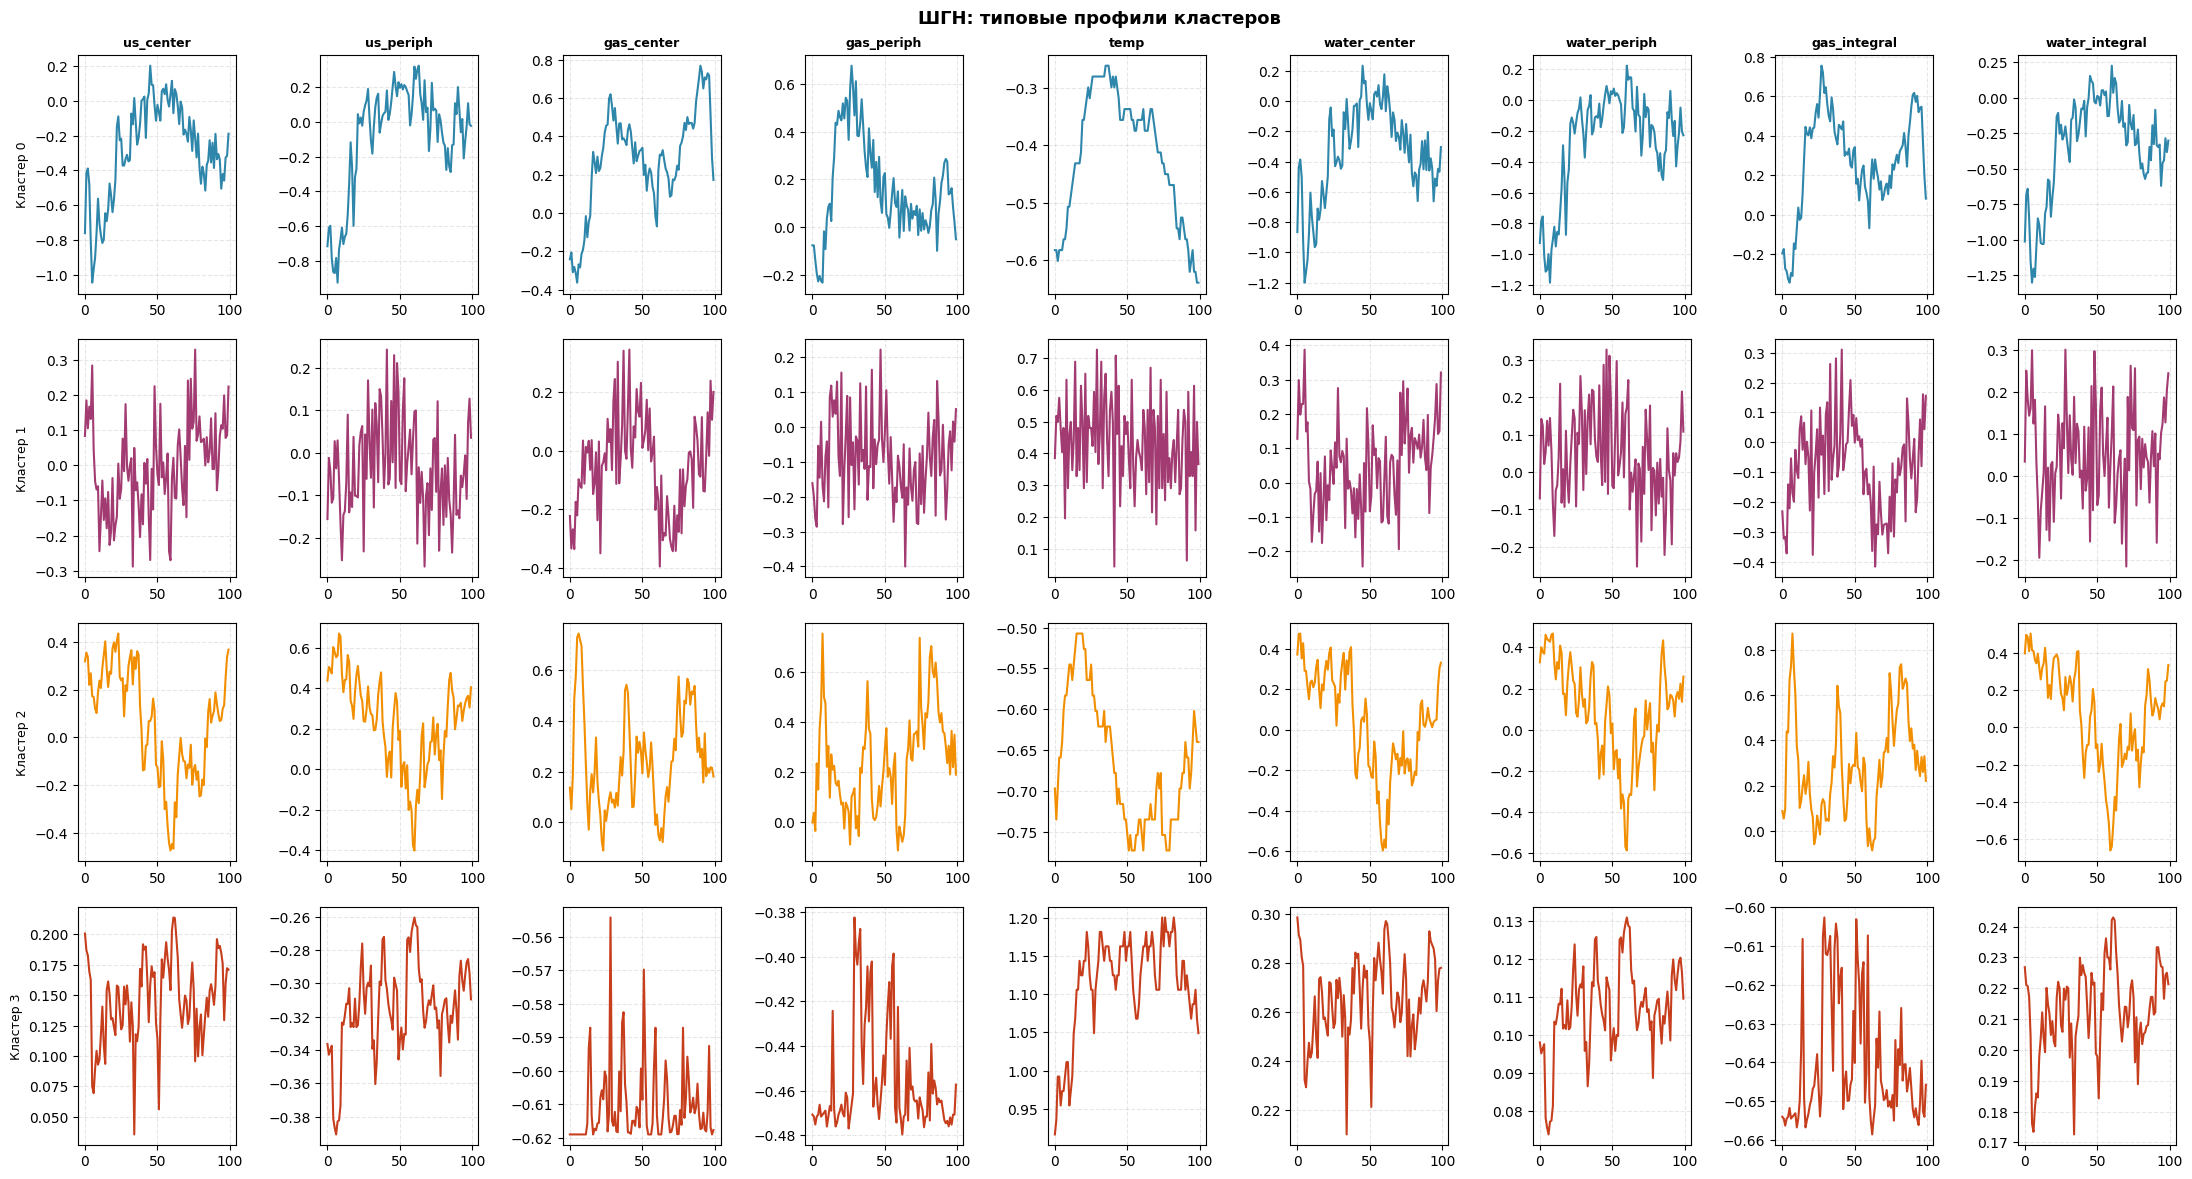

In [75]:
plot_cluster_profiles(Z_shgn, X_shgn, km_shgn, "ШГН", N_CLUSTERS["shgn"])

| Кластер | Состояние                 | Обоснование                                                                                                    |
| ------- | ------------------------- | -------------------------------------------------------------------------------------------------------------- |
| 0       | Фаза нефти (запуск цикла) | УЗ и обводнённость резко растут (+0.57, +0.70) — жидкость заполняет трубу после газовой фазы                   |
| 1       | Переход нефть→газ         | Газосодержание активно растёт (+0.42), остальные параметры умеренно нарастают — фаза меняется                  |
| 2       | Фаза газа                 | Температура минимальная (−0.67), газосодержание положительное, тренды малые — стабильный газовый режим         |
| 3       | Фаза воды                 | Температура максимальная (+1.11), газ минимальный (−0.64), тренды ~0, Std минимальный — чистая стабильная вода |

# ==== 7. СТАТИСТИКА КЛАСТЕРОВ ====

In [64]:
def print_cluster_profiles_stats(
    Z: np.ndarray,
    X: np.ndarray,
    km: KMeans,
    pump_type: str,
    n_neighbors: int = 50,
) -> None:
    rows: list[dict[str, Any]] = []
    for k in range(len(km.cluster_centers_)):
        profile = decode_centroid_by_nearest(Z, X, km.cluster_centers_[k], n_neighbors)
        for j, feature in enumerate(FEATURE_COLUMNS):
            col = profile[:, j]
            rows.append(
                {
                    "Кластер": k,
                    "Параметр": feature,
                    "Среднее": round(float(col.mean()), 4),
                    "Std": round(float(col.std()), 4),
                    "Min": round(float(col.min()), 4),
                    "Max": round(float(col.max()), 4),
                }
            )

    df = pd.DataFrame(rows)
    for k in range(len(km.cluster_centers_)):
        subset = df[df["Кластер"] == k][["Параметр", "Среднее", "Std", "Min", "Max"]]
        logger.info(f"\n{pump_type} | Кластер {k}:\n{subset.to_string(index=False)}")

In [65]:
print_cluster_profiles_stats(Z_ecn, X_ecn, km_ecn, "ЭЦН")

2026-02-23 22:18:56,501 - INFO - 
ЭЦН | Кластер 0:
      Параметр  Среднее    Std     Min     Max
     us_center  -0.3399 0.1080 -0.6201 -0.0884
     us_periph  -0.3343 0.0895 -0.5577 -0.1718
    gas_center  -0.3085 0.1040 -0.5893  0.0119
    gas_periph  -0.2994 0.1177 -0.5501 -0.0310
          temp   0.7678 0.0090  0.7525  0.7911
  water_center  -0.2721 0.1076 -0.5347 -0.0204
  water_periph  -0.3553 0.0865 -0.5700 -0.1901
  gas_integral  -0.3403 0.1025 -0.6187 -0.1102
water_integral  -0.3221 0.0957 -0.5461 -0.1337
2026-02-23 22:18:56,503 - INFO - 
ЭЦН | Кластер 1:
      Параметр  Среднее    Std     Min     Max
     us_center   0.9137 0.0408  0.8101  1.0134
     us_periph   0.7981 0.0436  0.6871  0.8672
    gas_center  -0.2093 0.1121 -0.4576  0.0251
    gas_periph  -0.6337 0.0198 -0.6700 -0.6208
          temp   0.0881 0.0285  0.0388  0.1365
  water_center   0.9973 0.0208  0.9416  1.0427
  water_periph   1.0761 0.0221  0.9992  1.1062
  gas_integral  -0.4625 0.0669 -0.6002 -0.3206
water

In [66]:
print_cluster_profiles_stats(Z_shgn, X_shgn, km_shgn, "ШГН")

2026-02-23 22:19:07,985 - INFO - 
ШГН | Кластер 0:
      Параметр  Среднее    Std     Min     Max
     us_center  -0.2807 0.2715 -1.0468  0.2023
     us_periph  -0.0858 0.3086 -0.9218  0.3200
    gas_center   0.2791 0.2639 -0.3641  0.7689
    gas_periph   0.1654 0.2060 -0.2332  0.6764
          temp  -0.4175 0.1119 -0.6401 -0.2605
  water_center  -0.3337 0.3099 -1.1999  0.2337
  water_periph  -0.2682 0.3326 -1.1846  0.2231
  gas_integral   0.2689 0.2494 -0.3448  0.7543
water_integral  -0.3415 0.3493 -1.3042  0.2258
2026-02-23 22:19:07,992 - INFO - 
ШГН | Кластер 1:
      Параметр  Среднее    Std     Min    Max
     us_center  -0.0032 0.1294 -0.2884 0.3298
     us_periph  -0.0348 0.1107 -0.2677 0.2431
    gas_center  -0.0499 0.1656 -0.3963 0.3455
    gas_periph  -0.0891 0.1208 -0.4005 0.2219
          temp   0.4334 0.1406  0.0432 0.7264
  water_center   0.0556 0.1260 -0.2439 0.3873
  water_periph   0.0459 0.1206 -0.2530 0.3271
  gas_integral  -0.0811 0.1540 -0.4167 0.3105
water_integral

# ==== 8. СОХРАНЕНИЕ АРТЕФАКТОВ ====

In [67]:
def save_artifacts(
    prefix: str,
    km: KMeans,
    labels: np.ndarray,
    Z: np.ndarray,
) -> None:
    artifact_dir = MODELS_DIR / prefix
    artifact_dir.mkdir(exist_ok=True, parents=True)

    with open(artifact_dir / "kmeans.pkl", "wb") as f:
        pickle.dump(km, f)

    np.save(artifact_dir / "labels.npy", labels)
    np.save(artifact_dir / "latents.npy", Z)

    logger.info(f"{prefix.upper()} артефакты сохранены → {artifact_dir.absolute()}")
    logger.info(f"  kmeans: {len(km.cluster_centers_)} кластеров | labels: {labels.shape} | latents: {Z.shape}")

In [68]:
save_artifacts("ecn", km_ecn, labels_ecn, Z_ecn)
save_artifacts("shgn", km_shgn, labels_shgn, Z_shgn)

2026-02-23 22:22:37,659 - INFO - ECN артефакты сохранены → c:\Users\aslan\Рабочий стол\Диплом\code\training\..\models\ecn
2026-02-23 22:22:37,661 - INFO -   kmeans: 3 кластеров | labels: (2052,) | latents: (2052, 32)
2026-02-23 22:22:37,668 - INFO - SHGN артефакты сохранены → c:\Users\aslan\Рабочий стол\Диплом\code\training\..\models\shgn
2026-02-23 22:22:37,670 - INFO -   kmeans: 4 кластеров | labels: (8343,) | latents: (8343, 8)
